# LGBM (LightGBM): Light Gradient Boosting Machine VSXGBM (XGBoost): eXtreme Gradient Boosting

## Objective: 

The objective of this assignment is to compare the performance of LightGBM and XGBoost classifiers on the Titanic dataset to predict passenger survival and analyze their strengths and weaknesses.

## Task 1: Exploratory Data Analysis (EDA):

### 1.	Load the Titanic dataset using Python's pandas library.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset("titanic")

# View first rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 2.	Check for missing values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### 3.	Explore data distributions using histograms and box plots.

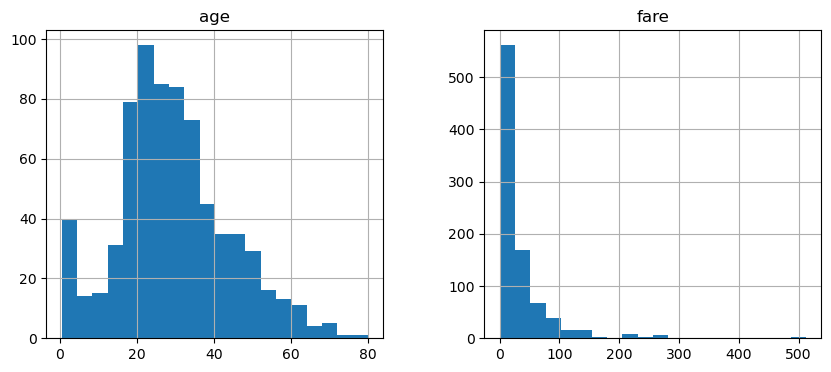

In [10]:
# Histogram

df[['age', 'fare']].hist(bins=20, figsize=(10,4))
plt.show()

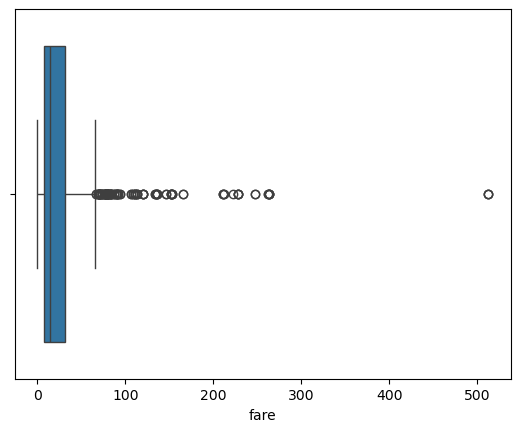

In [11]:
# Box Plots

sns.boxplot(x=df['fare'])
plt.show()

### 4.	Viualize relationships between features and survival using scatter plots and bar plots.

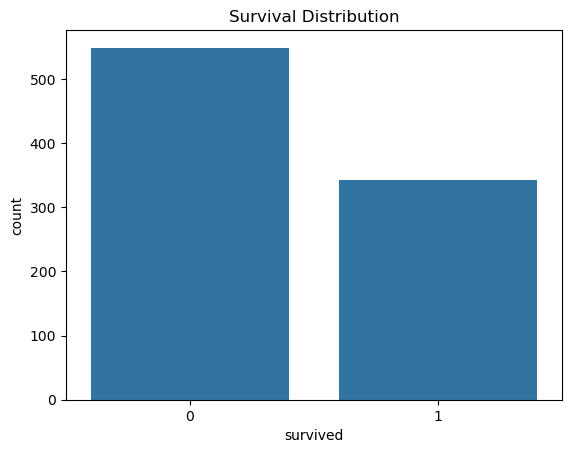

In [12]:
# Survival Count

sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()

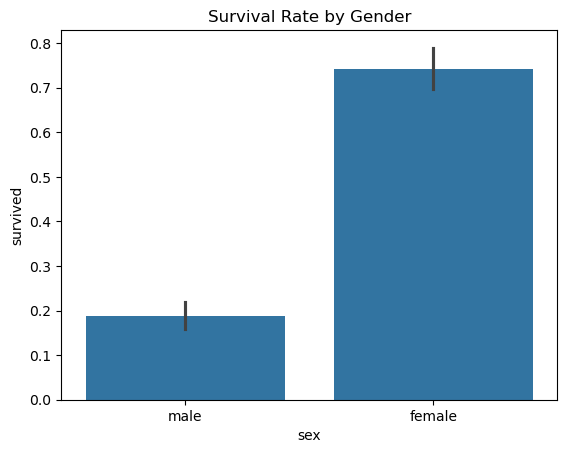

In [13]:
# Survival VS Gender 

sns.barplot(x='sex', y='survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

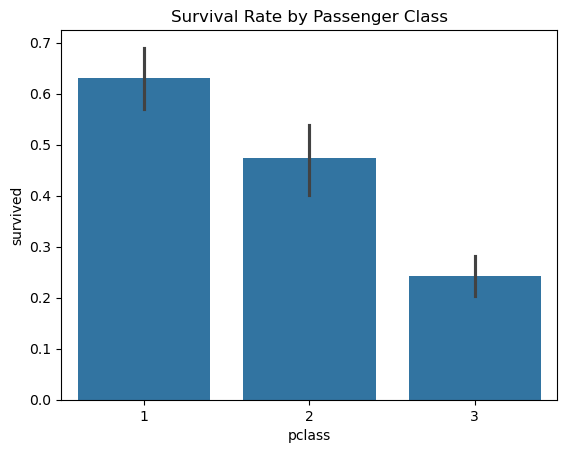

In [14]:
# Survical VS Passenger Class

sns.barplot(x='pclass', y='survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

## Task 2: Data Preprocessing:

### 1.	Impute missing values.

In [15]:
# Fill age with median
df['age'].fillna(df['age'].median(), inplace=True)

# Fill embarked with mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop deck (too many missing values)
df.drop(columns=['deck'], inplace=True)

C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_22608\374936073.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_22608\374936073.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

### 2.	Encode categorical variables using one-hot encoding or label encoding. 

In [16]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

### 3.	If needed you can apply more preprocessing methods on the given dataset.

In [17]:
X = df.drop(columns=['survived', 'alive', 'who', 'class', 'embark_town'])
y = df['survived']

## Task 3: Building Predictive Models:

### 1.	Split the preprocessed dataset into training and testing sets.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### 3.	Build predictive models using LightGBM and XGBoost algorithms.
### 4.	Train the models on the training set and evaluate their performance on the testing set.

In [20]:
#### Model 1: LightGBM

In [22]:
!pip install lightgbm
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 2.2 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.1 MB/s eta 0:00:00


C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Kaustubh Jadhav\Downloads\Ana

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000955 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 199
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LGBMClassifier(random_state=42)

In [23]:
lgb_preds = lgb_model.predict(X_test)

lgb_results = {
    "Accuracy": accuracy_score(y_test, lgb_preds),
    "Precision": precision_score(y_test, lgb_preds),
    "Recall": recall_score(y_test, lgb_preds),
    "F1 Score": f1_score(y_test, lgb_preds)
}

lgb_results

{'Accuracy': 0.8212290502793296,
 'Precision': 0.7916666666666666,
 'Recall': 0.7702702702702703,
 'F1 Score': 0.7808219178082192}

In [24]:
#### Model 2: XGBoost

In [25]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:29:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
xgb_preds = xgb_model.predict(X_test)

xgb_results = {
    "Accuracy": accuracy_score(y_test, xgb_preds),
    "Precision": precision_score(y_test, xgb_preds),
    "Recall": recall_score(y_test, xgb_preds),
    "F1 Score": f1_score(y_test, xgb_preds)
}

xgb_results

{'Accuracy': 0.8268156424581006,
 'Precision': 0.8028169014084507,
 'Recall': 0.7702702702702703,
 'F1 Score': 0.7862068965517242}

### 5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(X_train, y_train)
grid.best_params_


C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:29:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:29:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:29:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:29:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

## Task 4: Comparative Analysis:

### 1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.

In [28]:
comparison = pd.DataFrame([lgb_results, xgb_results],
                           index=['LightGBM', 'XGBoost'])
comparison

,Accuracy,Precision,Recall,F1 Score
LightGBM,0.821229,0.791667,0.77027,0.780822
XGBoost,0.826816,0.802817,0.77027,0.786207


### 2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

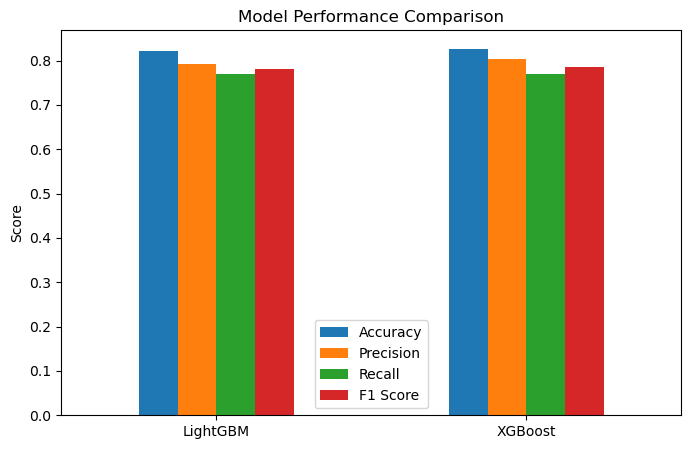

In [29]:
comparison.plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

#### Model Performance Comparison

The performance of LightGBM and XGBoost models was evaluated using four standard classification metrics: **Accuracy, Precision, Recall, and F1 Score**. The results are summarized below.

| Model     | Accuracy | Precision | Recall  | F1 Score |
|-----------|----------|-----------|---------|----------|
| LightGBM  | 0.821229 | 0.791667  | 0.770270| 0.780822 |
| XGBoost   | 0.826816 | 0.802817  | 0.770270| 0.786207 |

---

#### Interpretation and Analysis

- **Accuracy**:  
  XGBoost achieved a slightly higher accuracy (0.8268) compared to LightGBM (0.8212), indicating that XGBoost correctly classified a marginally higher proportion of passengers overall.

- **Precision**:  
  XGBoost shows better precision (0.8028) than LightGBM (0.7917), meaning XGBoost made fewer false positive predictions when identifying survivors.

- **Recall**:  
  Both models achieved the same recall value (0.7703), indicating that they are equally effective in identifying actual survivors.

- **F1 Score**:  
  XGBoost has a higher F1 score (0.7862) compared to LightGBM (0.7808), showing a better balance between precision and recall.

Overall, while both models perform strongly, **XGBoost demonstrates a slight edge in predictive performance**, particularly in precision and F1 score.

---

#### Conclusion and Practical Implications

#### Key Findings
- Both **LightGBM and XGBoost perform well** on the dataset, achieving accuracy above 82%.
- **XGBoost slightly outperforms LightGBM** in accuracy, precision, and F1 score.
- Both models show **equal recall**, indicating similar capability in capturing positive cases.

#### Practical Recommendations
- **LightGBM** is preferred when:
  - Faster training time is required
  - Working with very large datasets
  - Memory efficiency is important

- **XGBoost** is preferred when:
  - Slightly higher predictive performance is desired
  - Fine-grained hyperparameter tuning is needed
  - Robustness and stability are priorities

In conclusion, both models are highly effective for structured data problems, and the choice between them should be guided by the trade-off between **computational efficiency (LightGBM)** and **marginally better performance (XGBoost)**.
